In [70]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel
from typing import List

load_dotenv()


True

In [71]:
class OutlineModel(BaseModel):
    title: str
    sections: List[str]

class BlogModel(BaseModel):
    title: str
    content: str

In [72]:
class BlogState(TypedDict):
    topic : str
    outline : str
    blog : str

In [73]:
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [74]:
structured_outline_llm = llm.with_structured_output(OutlineModel)
structured_blog_llm = llm.with_structured_output(BlogModel)

In [75]:
def get_outline(state:BlogState):
    topic = state.get('topic')
    if topic:
        outline_prompt = f"write a outline for these {topic}"
        res = structured_outline_llm.invoke(outline_prompt)
        print('res->>>',res)
        print('\n\n')
        state['outline'] = res.model_dump()

    # print("state",state)
    # print("\n\n")
    return state

In [76]:
def get_blog(state:BlogState):
    outline = state.get('outline')

    if outline:
        blog_prompt = f"""
            Write a blog on these {state.get('topic')} using provided outline
            outline:
            {outline}
        """
        res = structured_blog_llm.invoke(blog_prompt)
        state['blog'] = res.model_dump()

    # print(outline)
    # print("\n\n")

    return state

In [77]:
graph = StateGraph(BlogState)

graph.add_node('get_outline',get_outline)
graph.add_node('get_blog',get_blog)

graph.add_edge(START,'get_outline')
graph.add_edge('get_outline','get_blog')
graph.add_edge('get_blog',END)

In [ ]:
workflow = graph.compile()

pipeline = workflow.invoke({'topic': 'local train in mumbai'})

print(pipeline.get('blog'))

res->>> title='Mumbai Suburban Railway: The Lifeline of the City' sections=['History and Origins of the Mumbai Local Train Network', 'The Three Primary Lines: Western, Central, and Harbour', 'Ticket Categories and Passenger Classes', 'The Unique Cultural Phenomenon of Commuting in Mumbai', 'Safety Challenges and Overcrowding Issues', 'Modernization and the Introduction of Air-Conditioned Coaches', 'Integration with the Mumbai Metro and Future Infrastructure']



{'topic': 'local train in mumbai', 'outline': {'title': 'Mumbai Suburban Railway: The Lifeline of the City', 'sections': ['History and Origins of the Mumbai Local Train Network', 'The Three Primary Lines: Western, Central, and Harbour', 'Ticket Categories and Passenger Classes', 'The Unique Cultural Phenomenon of Commuting in Mumbai', 'Safety Challenges and Overcrowding Issues', 'Modernization and the Introduction of Air-Conditioned Coaches', 'Integration with the Mumbai Metro and Future Infrastructure']}, 'blog': {'title': 'Mu

In [82]:
print(pipeline.get('blog')['content'])

The Mumbai Suburban Railway, often hailed as the 'Lifeline of the City,' serves as the backbone of the Mumbai metropolitan region. Its history dates back to 1853, when the first train in Asia puffed its way from Bori Bunder to Thane, marking the start of a legendary era in Indian transport. Today, the network is organized into three primary lines: the Western, Central, and Harbour lines, each serving specific geographic zones and connecting millions to their workplaces daily. Commuters can navigate the system through various ticket categories, including First and Second class, with the 'Season Pass' being the most economical and popular choice for regular travelers. Beyond its utilitarian function, commuting in Mumbai is a unique cultural phenomenon where lifelong friendships are forged in crowded compartments and 'Dabbawalas' perform logistical miracles every day. However, the system faces significant safety challenges due to extreme overcrowding and 'super dense crush loads,' which a

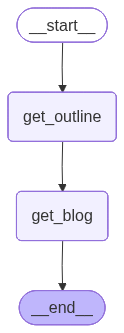

In [79]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [80]:
pipneline

{'topic': 'local train in mumbai',
 'outline': 'This outline provides a comprehensive look at the **Mumbai Suburban Railway**, famously known as the "Lifeline of Mumbai," covering its history, operations, culture, and future.\n\n---\n\n### **Outline: The Mumbai Local Train System**\n\n#### **I. Introduction**\n*   **The "Lifeline of Mumbai":** Why the city cannot function without it.\n*   **Historical Significance:** \n    *   The first train in India (1853) from Bori Bunder to Thane.\n    *   Evolution from steam engines to the modern electric system.\n*   **Scale and Scope:** One of the busiest commuter rail systems in the world (carrying over 7.5 million passengers daily).\n\n#### **II. The Network: Major Lines and Routes**\n*   **Western Line:** \n    *   Route: Churchgate to Dahanu Road.\n    *   Key Hubs: Mumbai Central, Dadar, Bandra, Andheri, Borivali.\n*   **Central Line (Main):** \n    *   Route: Chhatrapati Shivaji Maharaj Terminus (CSMT) to Kasara and Khopoli.\n    *   Key 